In [28]:
import pandas as pd
pesquisa = pd.read_csv('animal.csv', sep=';', encoding='latin-1')
pesquisa.columns
pesquisa =pesquisa.drop(pesquisa.columns[[1,2,3,4,5, 19]], axis=1)
pesquisa.head()




,Id,Qual a sua idade?,2. Qual o seu gênero?,Qual é o seu tipo de moradia?,Com quem você mora?,Você já tem animais de estimação?,Você já adotou ou tentou adotar um animal?,Quais são ou foram as principais dificuldades que você encontrou no processo de adoção?,Como você buscou ou buscaria um animal para adotar? \n,O que é mais importante para você ao escolher um animal? \nEscolha até 3,Que informações sobre o animal você considera importantes antes de demonstrar interesse na adoção? \n,O que faria você utilizar uma plataforma de adoção com mais frequência? \n,O que poderia fazer você perder a confiança ou desistir de utilizar uma plataforma de adoção?,Que tipo de informação sobre o animal você gostaria de saber antes de demonstrar interesse na adoção?,"Você resgata, cuida ou encaminha animais para adoção?",Qual é o seu perfil?,Quais são as principais dificuldades para encontrar lares adequados para os animais? \n,O que uma plataforma de adoção precisaria oferecer para facilitar seu trabalho?
0,1,28,Masculino,Casa com quintal.,Com familiares,Sim,"Sim, já adotei!",confiança por parte de ambas as partes.,Redes sociais;ONG ou abrigo;Feira de adoção;Pr...,Espécie ;Porte;,Sexo;Localização;Fotos e vídeos;Estado de saúde;,Informações mais completas sobre os animais;Pr...,Burocracia,NaN,Não,NaN,NaN,NaN
1,2,26,Femenino,Apartamento,Sozinho(a),Sim,"Sim, já adotei!",Geralmente adorei de algum parente ou peguei e...,Redes sociais;Sites ou aplicativos de adoção;I...,Porte;Temperamento;,Porte;Temperamento;Histórico do animal;Comport...,Filtros de busca mais precisos ;Visualização d...,Caso a plataforma n verifica-se os usuários qu...,Se o animal é tranquilo no caso n seja agressivo,Não,NaN,NaN,NaN
2,3,27,Femenino,Casa com quintal.,Com familiares,Sim,"Sim, já adotei!",Não ocorreu nenhuma dificuldade,Feira de adoção;Redes sociais;Indicação;,Temperamento;,Estado de saúde;Comportamento com outros anima...,Visualização de animais próximos à minha local...,dificuldade para entrar em contato com os resp...,"idade, porte, sexo, histórico de saúde, vacina...",Não,NaN,NaN,NaN
3,4,29,Femenino,Casa com quintal.,Com familiares,Sim,"Sim, já adotei!",Não tive dificuldades pois foi adoção entre am...,ONG ou abrigo;Feira de adoção;Protetores indep...,Estado de saúde;,Idade ;Estado de saúde;Vacinação;Castração;Nec...,Visualização de animais próximos à minha local...,Não ter informações sobre o estado de saúde do...,Se possui alguma doença contagiosa pois tenho ...,Sim,Realizo resgates de forma independente/ocasional,Dificuldade para encontrar interessados compat...,Seria bom um aplicativo onde o tutor pudesse c...
4,5,29,Femenino,Casa sem quintal,Sozinho(a),Não,"Sim, já adotei!",Nenhuma. Tirei da rua,Feira de adoção;,Temperamento;Estado de saúde;,Temperamento;Estado de saúde;Necessidades espe...,Filtros de busca mais precisos ;,Não sei dizer,Estado de saúde,Não,NaN,NaN,NaN


In [30]:
# Diagnóstico das colunas que serão usadas na análise
print(pesquisa.dtypes)
print('\nValores distintos por coluna:')
print(pesquisa.nunique(dropna=False).sort_values())

Id                                                                                                       int64
Qual a sua idade?                                                                                        int64
  2. Qual o seu gênero?                                                                                    str
 Qual é o seu tipo de moradia?                                                                             str
Com quem você mora?                                                                                        str
Você já tem animais de estimação?                                                                          str
 Você já adotou ou tentou adotar um animal?                                                                str
 Quais são ou foram as principais dificuldades que você encontrou no processo de adoção?                   str
Como você buscou ou buscaria um animal para adotar? \n                                                     str
 

Pergunta usada para separar os perfis:   2. Qual o seu gênero? 
Dimensões após a codificação: (28, 175)


Perfil,Masculino,Femenino
Pessoas,15,13
Idade média,29.6,27.5
Qual é o seu tipo de moradia?,Apartamento,Apartamento
Com quem você mora?,Com familiares,Com familiares
Você já tem animais de estimação?,Sim,Sim
Você já adotou ou tentou adotar um animal?,"Sim, já adotei!","Sim, já adotei!"
Quais são ou foram as principais dificuldades,Não informado,"Adaptação com outros animais, infestação de pa..."
Como você buscou ou buscaria um animal para a,Não informado,Feira de adoção;Redes sociais;Indicação;
O que é mais importante para você ao escolher,Não informado,Porte;Temperamento;Estado de saúde;
Que informações sobre o animal você considera,Não informado,Comportamento com outros animais;Porte;Estado ...


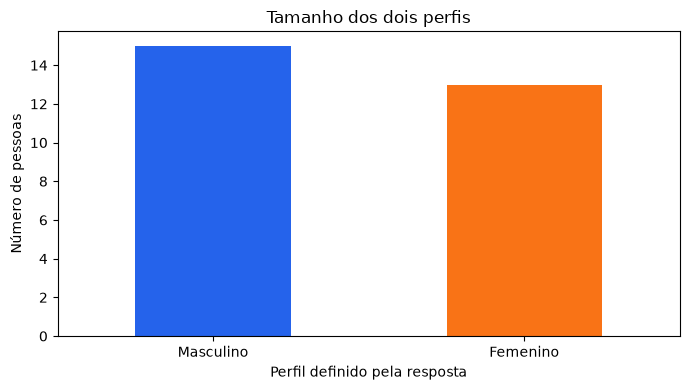

In [32]:
# Normalização das respostas categóricas e construção de dois perfis
import numpy as np
import matplotlib.pyplot as plt

base = pesquisa.drop(columns=['Id'], errors='ignore').copy()
coluna_idade = next(coluna for coluna in base.columns if 'idade' in coluna.lower())

base[coluna_idade] = pd.to_numeric(base[coluna_idade], errors='coerce')
colunas_numericas = base.select_dtypes(include='number').columns.tolist()
colunas_categoricas = base.select_dtypes(exclude='number').columns.tolist()
base[colunas_categoricas] = base[colunas_categoricas].fillna('Não informado').astype(str).apply(lambda coluna: coluna.str.strip())
base[coluna_idade] = base[coluna_idade].fillna(base[coluna_idade].median())

# One-hot encoding transforma cada resposta textual em uma coluna 0/1.
dados_codificados = pd.get_dummies(base, columns=colunas_categoricas, dtype=float)

# Padronização z-score: média 0 e desvio-padrão 1.
dados_normalizados = (dados_codificados - dados_codificados.mean()) / dados_codificados.std(ddof=0).replace(0, 1)
dados_normalizados = dados_normalizados.fillna(0)

# A coluna "perfil" tem muitos vazios; escolhemos a melhor pergunta binária respondida.
candidatas = []
for coluna in colunas_categoricas:
    contagens = base[coluna].value_counts()
    grupos_validos = contagens[contagens >= 3]
    if len(grupos_validos) >= 2:
        candidatas.append((grupos_validos.iloc[:2].min(), coluna, grupos_validos.iloc[:2].index.tolist()))
if not candidatas:
    raise ValueError('Não há uma coluna categórica com dois grupos suficientemente respondidos.')

_, coluna_grupo, valores_grupo = max(candidatas, key=lambda item: item[0])
resumo_perfis = []
for valor in valores_grupo:
    grupo = base[base[coluna_grupo] == valor]
    resumo = {'Perfil': valor, 'Pessoas': len(grupo), 'Idade média': round(grupo[coluna_idade].mean(), 1)}
    for coluna in colunas_categoricas:
        if coluna != coluna_grupo:
            resposta = grupo[coluna].mode()
            resumo[coluna.strip()[:45]] = resposta.iloc[0] if not resposta.empty else 'Não informado'
    resumo_perfis.append(resumo)

resumo_perfis = pd.DataFrame(resumo_perfis).set_index('Perfil')
print('Pergunta usada para separar os perfis:', coluna_grupo)
print('Dimensões após a codificação:', dados_normalizados.shape)
display(resumo_perfis.T)

ax = resumo_perfis['Pessoas'].plot(kind='bar', color=['#2563eb', '#f97316'], figsize=(7, 4), title='Tamanho dos dois perfis')
ax.set_xlabel('Perfil definido pela resposta')
ax.set_ylabel('Número de pessoas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
# Exploração de padrões comportamentais além do sexo
colunas_comportamentais = [
    coluna for coluna in base.columns
    if any(termo in coluna.lower() for termo in ['adotou', 'animais de estimação', 'resgata'])
]
for coluna in colunas_comportamentais:
    print(f'\n{coluna.strip()}')
    print(base[coluna].value_counts(dropna=False))

print('\nCombinação entre experiência de adoção e atuação em resgate:')
coluna_adocao = next((coluna for coluna in base.columns if 'adotou' in coluna.lower()), None)
coluna_resgate = next((coluna for coluna in base.columns if 'resgata' in coluna.lower()), None)
if coluna_adocao and coluna_resgate:
    print(pd.crosstab(base[coluna_adocao], base[coluna_resgate]))


Você já tem animais de estimação?
Você já tem animais de estimação?
Sim    18
Não    10
Name: count, dtype: int64

Você já adotou ou tentou adotar um animal?
 Você já adotou ou tentou adotar um animal?
Sim, já adotei!                      20
Não tenho interesse.                  4
Tenho interesse mas nunca tentei.     4
Name: count, dtype: int64

Você resgata, cuida ou encaminha animais para adoção?
 Você resgata, cuida ou encaminha animais para adoção?
Não              23
Não informado     4
Sim               1
Name: count, dtype: int64

Combinação entre experiência de adoção e atuação em resgate:
 Você resgata, cuida ou encaminha animais para adoção?  Não  Não informado  \
 Você já adotou ou tentou adotar um animal?                                  
Não tenho interesse.                                      0              4   
Sim, já adotei!                                          19              0   
Tenho interesse mas nunca tentei.                         4              0   

 V

Perfis comportamentais encontrados:


,Pessoas,Idade média,Com animais (%)
Perfil comportamental,,,
Adotante experiente,20,28.4,75.0
Interessado sem experiência,4,23.0,50.0
Sem interesse,4,35.0,25.0


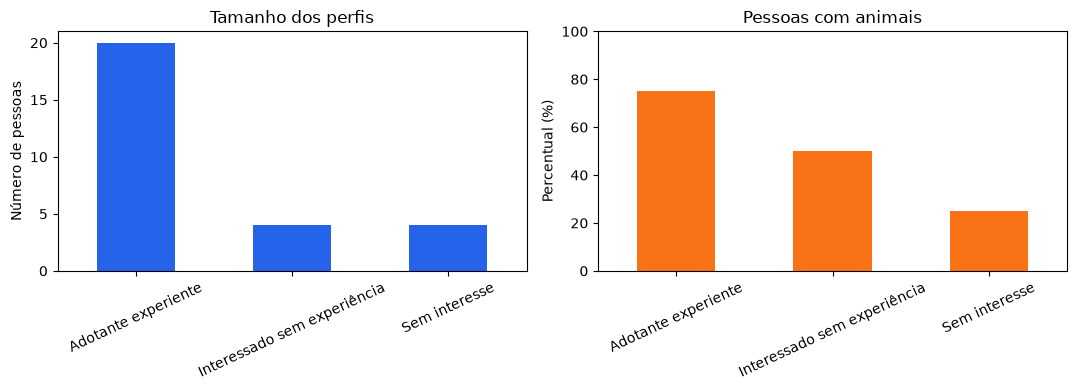

In [37]:
# Perfis comportamentais baseados na experiência com adoção
coluna_adocao = next(coluna for coluna in base.columns if 'adotou' in coluna.lower())
coluna_animais = next(coluna for coluna in base.columns if 'animais de estimação' in coluna.lower())

respostas_adocao = base[coluna_adocao].str.lower()
base['Perfil comportamental'] = np.select(
    [
        respostas_adocao.str.contains('já adotei', na=False),
        respostas_adocao.str.contains('não tenho interesse', na=False),
        respostas_adocao.str.contains('tenho interesse', na=False)
    ],
    ['Adotante experiente', 'Sem interesse', 'Interessado sem experiência'],
    default='Não informado'
)

perfis_comportamentais = base.groupby('Perfil comportamental').agg(
    Pessoas=('Perfil comportamental', 'size'),
    **{
        'Idade média': (coluna_idade, 'mean'),
        'Com animais (%)': (coluna_animais, lambda serie: (serie == 'Sim').mean() * 100)
    }
).round(1).sort_values('Pessoas', ascending=False)

print('Perfis comportamentais encontrados:')
display(perfis_comportamentais)

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
perfis_comportamentais['Pessoas'].plot(kind='bar', ax=eixos[0], color='#2563eb', title='Tamanho dos perfis')
eixos[0].set_xlabel('')
eixos[0].set_ylabel('Número de pessoas')
eixos[0].tick_params(axis='x', rotation=25)
perfis_comportamentais['Com animais (%)'].plot(kind='bar', ax=eixos[1], color='#f97316', title='Pessoas com animais')
eixos[1].set_xlabel('')
eixos[1].set_ylabel('Percentual (%)')
eixos[1].set_ylim(0, 100)
eixos[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

Respostas originais de moradia:
 Qual é o seu tipo de moradia?
Apartamento          17
Casa com quintal.     9
Casa sem quintal      2
Name: count, dtype: int64

Perfil por grupo de moradia:


,Pessoas,Com animais,Sem animais,Com animais (%),Idade média
Grupo de moradia,,,,,
Sem pátio (apartamento),17,9,8,52.9,24.9
Casa com pátio,9,9,0,100.0,33.3
Sem pátio (casa),2,0,2,0.0,39.0



Percentual de pessoas com animais em cada grupo:


Tem animais,Com animais (%)
Grupo de moradia,
Casa com pátio,100.0
Sem pátio (apartamento),52.9
Sem pátio (casa),0.0


Diferença entre casa com pátio e apartamento: 47.1 pontos percentuais.


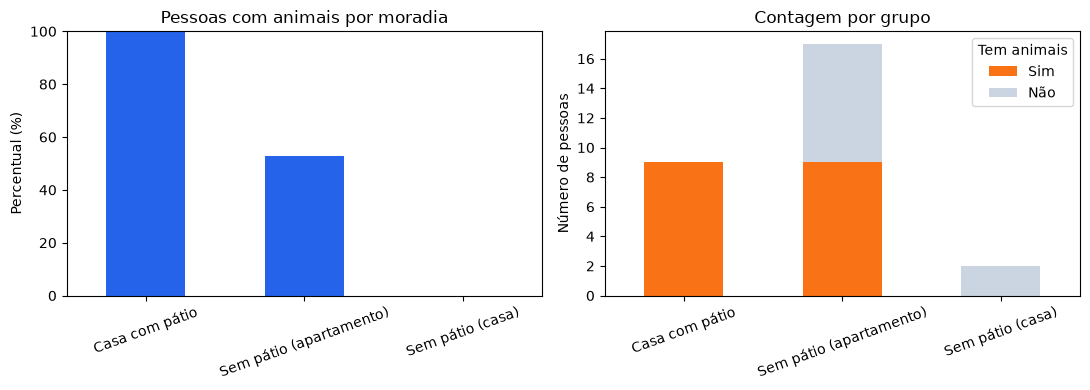

In [ ]:
# Relação entre ter casa com pátio e ter animais
import unicodedata

coluna_moradia = next(coluna for coluna in base.columns if 'tipo de moradia' in coluna.lower())
coluna_animais = next(coluna for coluna in base.columns if 'animais de estimação' in coluna.lower())

def remover_acentos(texto):
    return ''.join(
        caractere for caractere in unicodedata.normalize('NFKD', str(texto))
        if not unicodedata.combining(caractere)
    ).casefold()

moradia_normalizada = base[coluna_moradia].map(remover_acentos)
base['Grupo de moradia'] = np.select(
    [
        moradia_normalizada.str.contains('casa', na=False) & moradia_normalizada.str.contains('quintal|patio', regex=True, na=False),
        moradia_normalizada.str.contains('apartamento', na=False)
    ],
    ['Casa com pátio', 'Sem pátio (apartamento)'],
    default='Outra moradia'
)

base['Tem animais'] = base[coluna_animais].eq('Sim')
contagem_moradia_animais = pd.crosstab(base['Grupo de moradia'], base['Tem animais']).rename(columns={False: 'Não', True: 'Sim'})
percentual_moradia_animais = (contagem_moradia_animais.div(contagem_moradia_animais.sum(axis=1), axis=0) * 100).round(1)

analise_moradia = pd.DataFrame({
    'Pessoas': contagem_moradia_animais.sum(axis=1),
    'Com animais': contagem_moradia_animais.get('Sim', 0),
    'Sem animais': contagem_moradia_animais.get('Não', 0),
    'Com animais (%)': percentual_moradia_animais.get('Sim', 0),
    'Idade média': base.groupby('Grupo de moradia')[coluna_idade].mean().round(1)
}).sort_values('Pessoas', ascending=False)

print('Respostas originais de moradia:')
print(base[coluna_moradia].value_counts())
print('\nPerfil por grupo de moradia:')
display(analise_moradia)
print('\nPercentual de pessoas com animais em cada grupo:')
display(percentual_moradia_animais[['Sim']].rename(columns={'Sim': 'Com animais (%)'}))

if {'Casa com pátio', 'Sem pátio (apartamento)'}.issubset(percentual_moradia_animais.index):
    diferenca_pontos = percentual_moradia_animais.loc['Casa com pátio', 'Sim'] - percentual_moradia_animais.loc['Sem pátio (apartamento)', 'Sim']
    print(f'Diferença: {diferenca_pontos:.1f} pontos percentuais entre casa com pátio e apartamento.')

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
percentual_moradia_animais['Sim'].plot(kind='bar', ax=eixos[0], color='#2563eb', title='Pessoas com animais por moradia')
eixos[0].set_xlabel('')
eixos[0].set_ylabel('Percentual (%)')
eixos[0].set_ylim(0, 100)
eixos[0].tick_params(axis='x', rotation=20)
contagem_moradia_animais[['Sim', 'Não']].plot(kind='bar', stacked=True, ax=eixos[1], color=['#f97316', '#cbd5e1'], title='Contagem por grupo')
eixos[1].set_xlabel('')
eixos[1].set_ylabel('Número de pessoas')
eixos[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()